# Analiza czynników ryzyka choroby serca — UCI Heart Disease

**Praca zaliczeniowa** · Analiza i wizualizacja danych (Pandas) · WSB Merito Chorzów 2025/2026 lato.
**Sekcja projektowa:** Michał Wesołowski, Szymon Woźny.

Statystyczna analiza publicznego zbioru **UCI Heart Disease (Cleveland)** — od statystyki
opisowej, przez wnioskowanie (testy hipotez, korelacja, regresja, ANOVA, proporcje),
po model predykcyjny (regresja logistyczna + ROC/AUC). Każda analiza zawiera **sprawdzenie
założeń** i — gdy trzeba — odporną alternatywę.

## Pytania badawcze
1. Czy cholesterol różni się między chorymi a zdrowymi? — *test t / Mann–Whitney*
2. Czy maksymalne tętno zależy od wieku? — *korelacja + regresja prosta*
3. Czy maksymalne tętno można przewidzieć z wieku, ciśnienia i obniżenia ST? — *regresja wieloraka*
4. Czy maksymalne tętno różni się między typami bólu w klatce? — *ANOVA + Tukey*
5. Czy częstość choroby zależy od płci, a dławica wysiłkowa od statusu choroby? — *test proporcji / chi-kwadrat*
6. Jak modelować prawdopodobieństwo choroby? — *regresja logistyczna + ROC/AUC*

## 0. Konfiguracja

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
RNG = np.random.default_rng(42)
pd.set_option("display.width", 120)

## 1. Wczytanie i czyszczenie danych

Plik surowy `data/raw/processed.cleveland.data`: 303 obserwacje, 14 kolumn, bez nagłówka,
braki danych oznaczone `?`. Kroki: nadanie nazw kolumn → `?`→`NaN` → konwersja `ca`/`thal`
na typ liczbowy → binaryzacja celu (`target = num > 0`) → rzutowanie kategorii.

In [2]:
COLS = ["age","sex","cp","trestbps","chol","fbs","restecg",
        "thalach","exang","oldpeak","slope","ca","thal","num"]
raw = pd.read_csv("data/raw/processed.cleveland.data", header=None, names=COLS, na_values="?")
print("Surowy kształt:", raw.shape)
print("Braki danych na kolumnę:\n", raw.isna().sum()[lambda s: s > 0])

df = raw.copy()
df["target"] = (df["num"] > 0).astype(int)     # binaryzacja: 0 = brak, 1 = choroba
df = df.drop(columns="num")

before = len(df)
df = df.dropna().reset_index(drop=True)          # usuwamy ~6 wierszy z brakami w ca/thal
print(f"\nUsunięto {before - len(df)} wierszy z brakami; pozostało {len(df)}.")

CATS = ["sex","cp","fbs","restecg","exang","slope","thal","target"]
for c in CATS:
    df[c] = df[c].astype("int").astype("category")
df["ca"] = df["ca"].astype(int)
df.head()

Surowy kształt: (303, 14)
Braki danych na kolumnę:
 ca      4
thal    2
dtype: int64

Usunięto 6 wierszy z brakami; pozostało 297.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0


## 2. Przegląd i bilans klas

In [3]:
df.info()
print("\nRozkład celu (0=brak, 1=choroba):")
print(df["target"].value_counts().sort_index())
print(f"Udział chorych: {df['target'].astype(int).mean():.1%}")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       297 non-null    float64 
 1   sex       297 non-null    category
 2   cp        297 non-null    category
 3   trestbps  297 non-null    float64 
 4   chol      297 non-null    float64 
 5   fbs       297 non-null    category
 6   restecg   297 non-null    category
 7   thalach   297 non-null    float64 
 8   exang     297 non-null    category
 9   oldpeak   297 non-null    float64 
 10  slope     297 non-null    category
 11  ca        297 non-null    int64   
 12  thal      297 non-null    category
 13  target    297 non-null    category
dtypes: category(8), float64(5), int64(1)
memory usage: 16.5 KB

Rozkład celu (0=brak, 1=choroba):
target
0    160
1    137
Name: count, dtype: int64
Udział chorych: 46.1%


,age,trestbps,chol,thalach,oldpeak,ca
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,131.693603,247.350168,149.599327,1.055556,0.676768
std,9.049736,17.762806,51.997583,22.941562,1.166123,0.938965
min,29.000000,94.000000,126.000000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.000000,133.000000,0.000000,0.000000
50%,56.000000,130.000000,243.000000,153.000000,0.800000,0.000000
75%,61.000000,140.000000,276.000000,166.000000,1.600000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000


## 3. Eksploracja i statystyka opisowa  *(W1, U1)*

Porównanie podstawowych statystyk cech ciągłych w grupach chorych/zdrowych oraz przegląd
rozkładów i korelacji. To podstawa do formułowania hipotez w kolejnych krokach.

In [4]:
CONT = ["age","trestbps","chol","thalach","oldpeak"]
summary = df.groupby("target", observed=True)[CONT].agg(["mean","std","median"]).round(1)
summary

age             trestbps                chol              thalach              oldpeak            
        mean  std median     mean   std median   mean   std median    mean   std median    mean  std median
target                                                                                                     
0       52.6  9.6   52.0    129.2  16.4  130.0  243.5  53.8  235.5   158.6  19.0  161.0     0.6  0.8    0.2
1       56.8  7.9   58.0    134.6  18.9  130.0  251.9  49.7  253.0   139.1  22.7  142.0     1.6  1.3    1.4

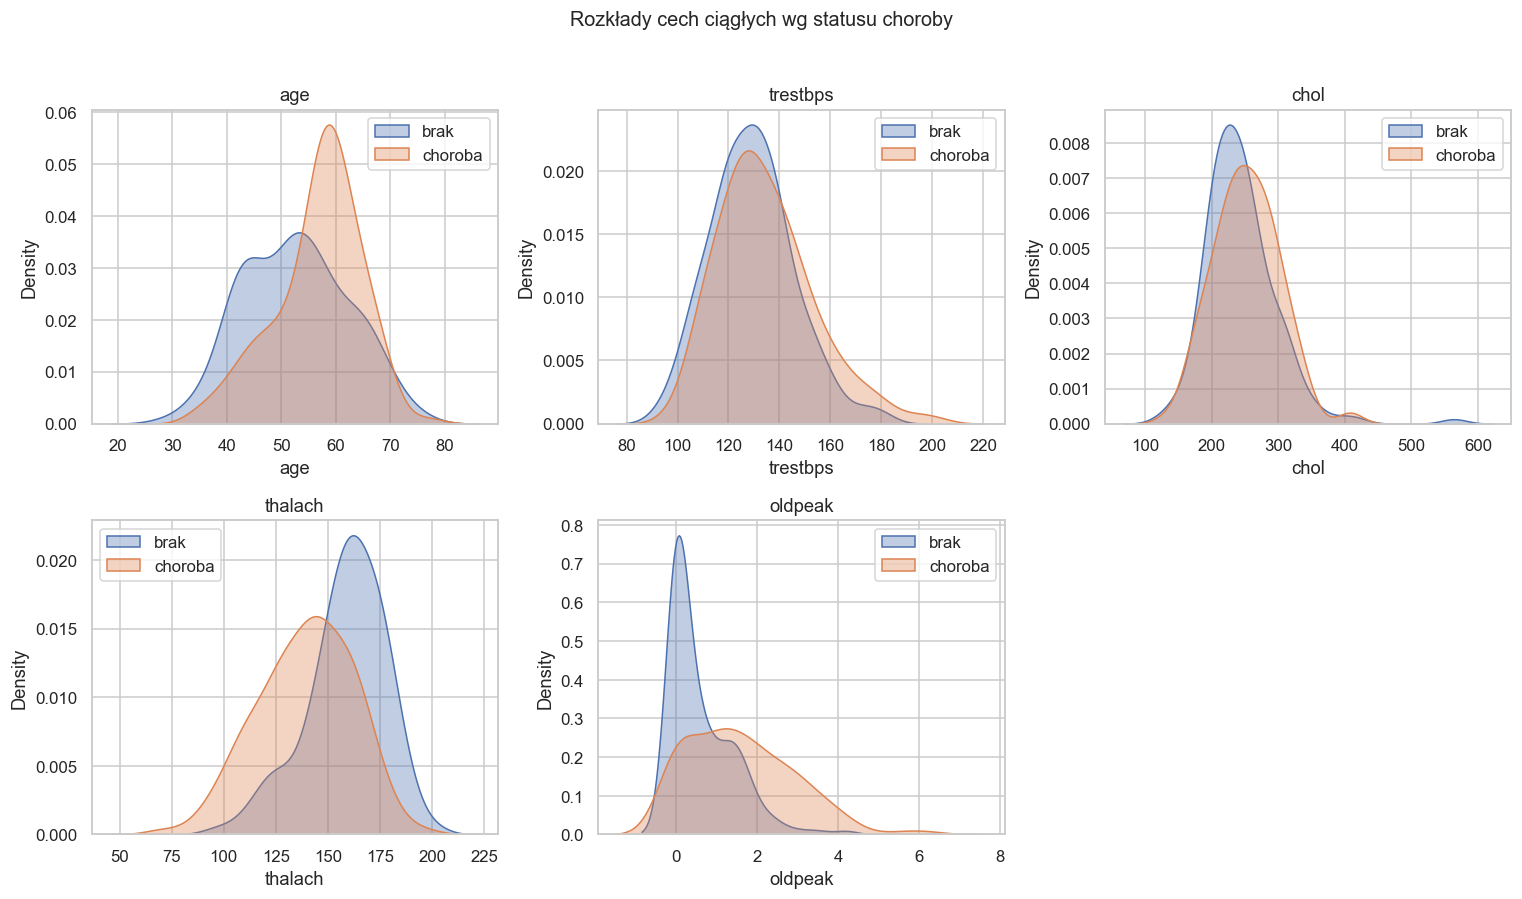

In [5]:
# Rozkłady cech ciągłych wg statusu choroby
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, CONT):
    for t, sub in df.groupby("target", observed=True):
        sns.kdeplot(sub[col], ax=ax, fill=True, alpha=.35,
                    label=("choroba" if int(t)==1 else "brak"))
    ax.set_title(col); ax.legend(title="")
axes.flat[-1].axis("off")
fig.suptitle("Rozkłady cech ciągłych wg statusu choroby", y=1.02, fontsize=13)
fig.tight_layout(); fig.savefig(FIG/"01_rozklady.png", bbox_inches="tight"); plt.show()

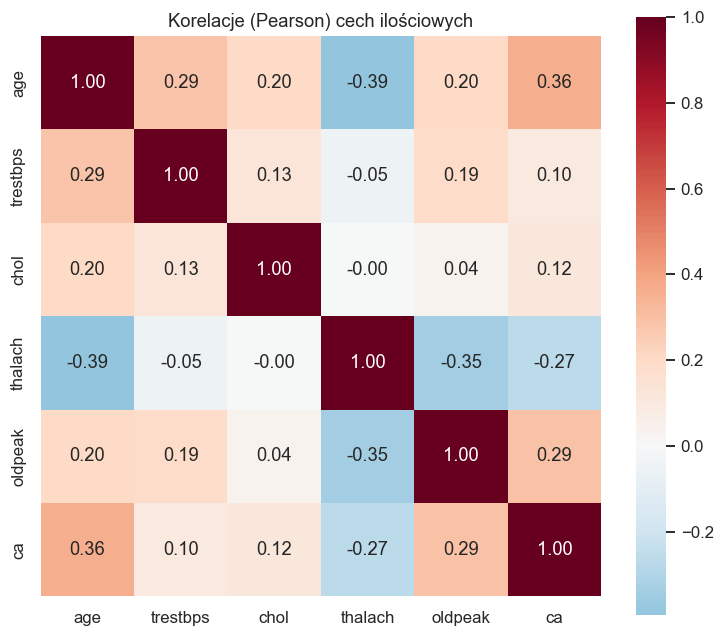

In [6]:
# Mapa korelacji cech ciągłych
fig, ax = plt.subplots(figsize=(7, 6))
corr = df[CONT + ["ca"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Korelacje (Pearson) cech ilościowych")
fig.tight_layout(); fig.savefig(FIG/"02_korelacje.png", bbox_inches="tight"); plt.show()

## RQ1 — Czy cholesterol różni się między chorymi a zdrowymi?  *(W2, W3)*

- **H0**: średni cholesterol jest taki sam w obu grupach.  **H1**: różni się.
- **Test (W2)**: dwupróbkowy test t Welcha (nie zakłada równych wariancji).
- **Założenia (W3)**: normalność w grupach (Shapiro–Wilk + Q-Q), niezależność obserwacji.
  Przy złamaniu normalności — **Mann–Whitney U**. Sprawdzamy też równość wariancji (Levene).
- **Wielkość efektu**: Cohen's d.

In [7]:
g1 = df.loc[df["target"].astype(int)==1, "chol"]   # choroba
g0 = df.loc[df["target"].astype(int)==0, "chol"]   # brak

sh1, sh0 = stats.shapiro(g1), stats.shapiro(g0)
lev = stats.levene(g1, g0)
print(f"Shapiro choroba: W={sh1.statistic:.3f}, p={sh1.pvalue:.4f}")
print(f"Shapiro brak:    W={sh0.statistic:.3f}, p={sh0.pvalue:.4f}")
print(f"Levene (równość wariancji): p={lev.pvalue:.4f}")

t = stats.ttest_ind(g1, g0, equal_var=False)       # Welch
mw = stats.mannwhitneyu(g1, g0, alternative="two-sided")
n1, n0 = len(g1), len(g0)
sp = np.sqrt(((n1-1)*g1.var(ddof=1) + (n0-1)*g0.var(ddof=1)) / (n1+n0-2))
d = (g1.mean() - g0.mean()) / sp
print(f"\nŚrednie: choroba={g1.mean():.1f}  brak={g0.mean():.1f}  (mg/dl)")
print(f"Welch t: t={t.statistic:.3f}, p={t.pvalue:.4f}")
print(f"Mann–Whitney U: p={mw.pvalue:.4f}")
print(f"Cohen's d = {d:.3f}")

Shapiro choroba: W=0.990, p=0.4319
Shapiro brak:    W=0.899, p=0.0000
Levene (równość wariancji): p=0.7210

Średnie: choroba=251.9  brak=243.5  (mg/dl)
Welch t: t=1.392, p=0.1650
Mann–Whitney U: p=0.0467
Cohen's d = 0.161


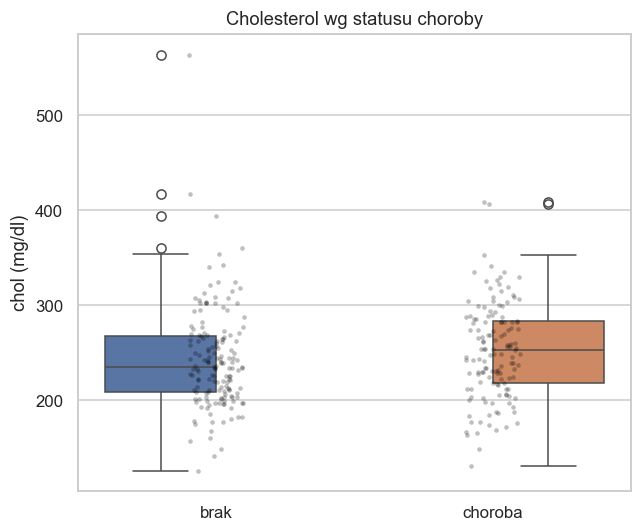

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df.assign(status=df["target"].map({0:"brak",1:"choroba"})),
            x="status", y="chol", hue="status", legend=False, ax=ax)
sns.stripplot(data=df.assign(status=df["target"].map({0:"brak",1:"choroba"})),
              x="status", y="chol", color="black", alpha=.25, size=3, ax=ax)
ax.set_title("Cholesterol wg statusu choroby"); ax.set_xlabel(""); ax.set_ylabel("chol (mg/dl)")
fig.tight_layout(); fig.savefig(FIG/"03_rq1_cholesterol.png", bbox_inches="tight"); plt.show()

**Interpretacja RQ1.** Średni cholesterol: choroba **251,9** vs brak **243,5** mg/dl. Założenie
normalności jest **złamane** w grupie zdrowych (Shapiro p<0,001), więc wynik testu t Welcha
(t=1,39, **p=0,165** — nieistotny) traktujemy ostrożnie. Odporny **Mann–Whitney daje p=0,047**
(granicznie istotny), lecz wielkość efektu jest znikoma (**Cohen's d=0,16**). Wniosek: cholesterol
*sam w sobie* słabo różnicuje chorych i zdrowych — co dobrze pokazuje, że rozstrzygnięcie zależy
od spełnienia założeń i doboru testu (efekt **W2/W3**).

## RQ2 — Czy maksymalne tętno (`thalach`) zależy od wieku?  *(W2, W3)*

- **Test (W2)**: korelacja Pearsona + **prosta regresja liniowa** OLS (`thalach ~ age`):
  test F modelu, test t nachylenia, R².
- **Założenia (W3)**: liniowość, normalność reszt (Q-Q), homoskedastyczność, brak punktów
  wpływowych (odległość Cooka). Alternatywa odporna: korelacja **Spearmana**.

In [9]:
pear = stats.pearsonr(df["age"], df["thalach"])
spear = stats.spearmanr(df["age"], df["thalach"])
print(f"Pearson r={pear.statistic:.3f}, p={pear.pvalue:.2e}")
print(f"Spearman rho={spear.statistic:.3f}, p={spear.pvalue:.2e}")

m = smf.ols("thalach ~ age", data=df).fit()
print(m.summary())

Pearson r=-0.395, p=1.67e-12
Spearman rho=-0.393, p=2.21e-12
                            OLS Regression Results                            
Dep. Variable:                thalach   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     54.39
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.67e-12
Time:                        20:48:34   Log-Likelihood:                -1326.3
No. Observations:                 297   AIC:                             2657.
Df Residuals:                     295   BIC:                             2664.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

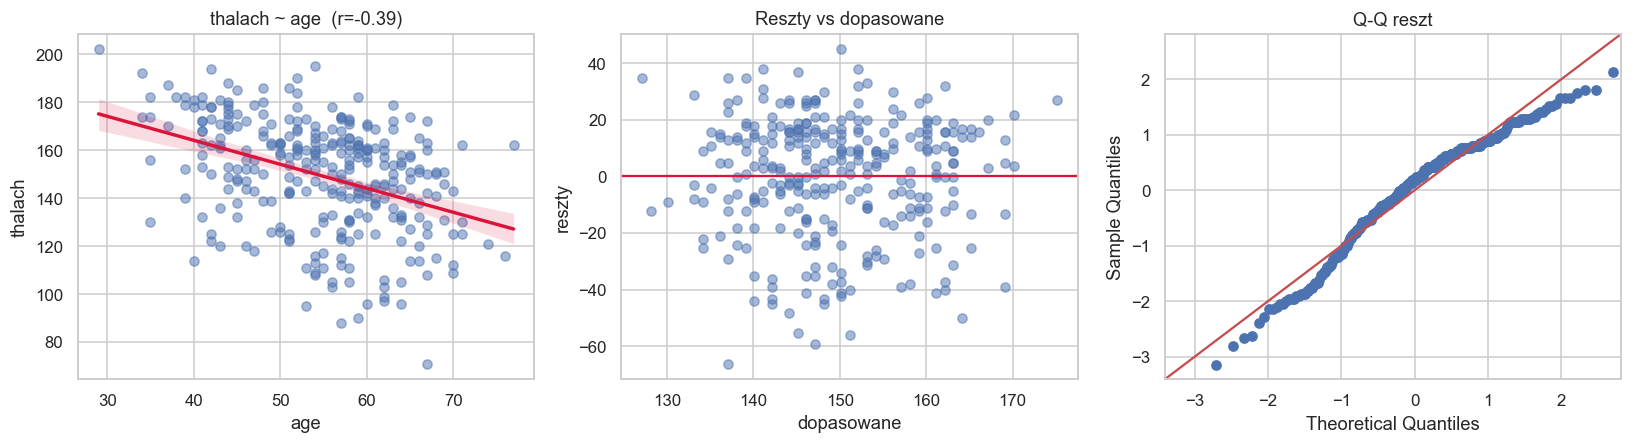

In [10]:
# Diagnostyka regresji (W3): dopasowanie, reszty vs dopasowane, Q-Q
fitted, resid = m.fittedvalues, m.resid
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
sns.regplot(x=df["age"], y=df["thalach"], ax=ax[0],
            line_kws=dict(color="crimson"), scatter_kws=dict(alpha=.5))
ax[0].set_title(f"thalach ~ age  (r={pear.statistic:.2f})")
ax[1].scatter(fitted, resid, alpha=.5); ax[1].axhline(0, color="crimson")
ax[1].set_xlabel("dopasowane"); ax[1].set_ylabel("reszty"); ax[1].set_title("Reszty vs dopasowane")
sm.qqplot(resid, line="45", fit=True, ax=ax[2]); ax[2].set_title("Q-Q reszt")
fig.tight_layout(); fig.savefig(FIG/"04_rq2_regresja.png", bbox_inches="tight"); plt.show()

**Interpretacja RQ2.** Wyraźna **ujemna** zależność tętna maksymalnego od wieku: Pearson
**r=−0,40** (p≈1,7e−12), Spearman ρ=−0,39 (zgodne → związek monotoniczny i w przybliżeniu
liniowy). Regresja: **thalach ≈ 204,2 − 1,00·age**, czyli spadek o ok. **1 uderzenie/min na
każdy rok** życia; model istotny (F=54,4, p≈1,7e−12), lecz wyjaśnia jedynie **R²=15,6%**
wariancji. Diagnostyka: reszty lekko lewoskośne (Omnibus/JB istotne, skośność −0,66) —
umiarkowane odchylenie od normalności sugeruje dodanie kolejnych predyktorów (→ RQ3).

## RQ3 — Czy `thalach` można przewidzieć z `age` + `trestbps` + `oldpeak`?  *(W2, W3)*

- **Test (W2)**: wieloraka regresja liniowa OLS — test F modelu, testy t współczynników, skoryg. R².
- **Założenia (W3)**: reszty (vs dopasowane, Q-Q), **współliniowość (VIF)**, punkty wpływowe
  (odległość Cooka, próg 4/n).

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

PRED = ["age", "trestbps", "oldpeak"]
m3 = smf.ols("thalach ~ age + trestbps + oldpeak", data=df).fit()
print(m3.summary())

Xv = sm.add_constant(df[PRED])
vif = pd.DataFrame({"zmienna": Xv.columns,
                    "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]})
print("\nVIF (współliniowość):\n", vif.to_string(index=False))

                            OLS Regression Results                            
Dep. Variable:                thalach   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     31.40
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.25e-17
Time:                        20:48:35   Log-Likelihood:                -1310.0
No. Observations:                 297   AIC:                             2628.
Df Residuals:                     293   BIC:                             2643.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    187.2908     10.006     18.717      0.0

Obserwacji powyżej progu Cooka: 16


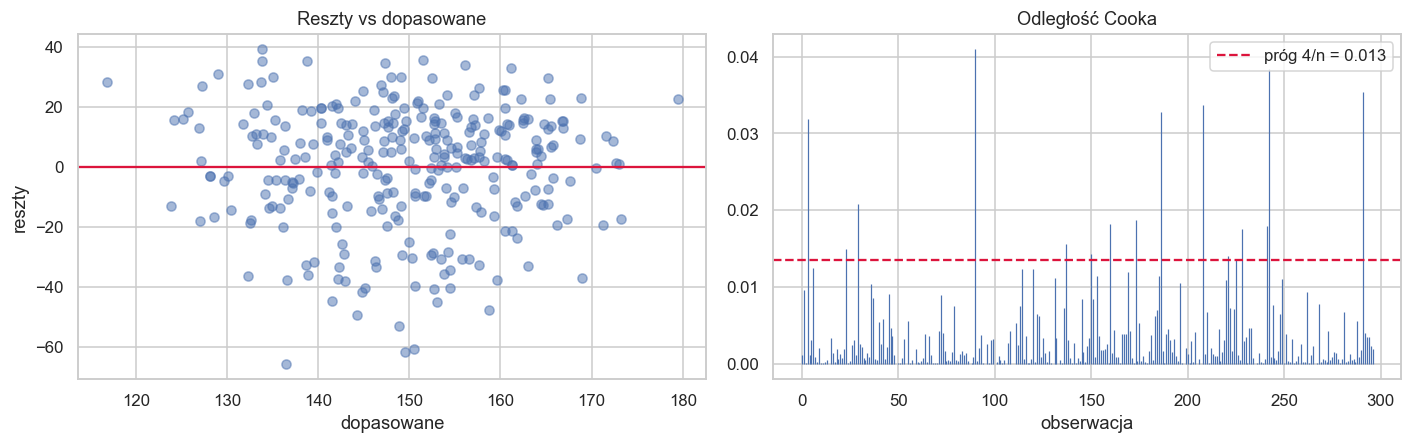

In [12]:
infl = m3.get_influence()
cooks = infl.cooks_distance[0]
thr = 4 / len(df)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].scatter(m3.fittedvalues, m3.resid, alpha=.5); ax[0].axhline(0, color="crimson")
ax[0].set_xlabel("dopasowane"); ax[0].set_ylabel("reszty"); ax[0].set_title("Reszty vs dopasowane")
ax[1].vlines(range(len(cooks)), 0, cooks, lw=.8)
ax[1].axhline(thr, color="crimson", ls="--", label=f"próg 4/n = {thr:.3f}")
ax[1].set_title("Odległość Cooka"); ax[1].set_xlabel("obserwacja"); ax[1].legend()
print(f"Obserwacji powyżej progu Cooka: {(cooks > thr).sum()}")
fig.tight_layout(); fig.savefig(FIG/"05_rq3_multi.png", bbox_inches="tight"); plt.show()

**Interpretacja RQ3.** Model: `thalach ≈ 187,3 − 0,94·age + 0,15·trestbps − 5,84·oldpeak`.
Wszystkie predyktory istotne (age p<0,001; trestbps p=0,033; oldpeak p<0,001), **skoryg. R²=0,236**
— wyraźnie lepiej niż model prosty z RQ2 (0,153). **VIF ≈ 1,1** dla każdego predyktora → brak
współliniowości (duża „Cond. No.” wynika z różnej skali zmiennych, nie z korelacji predyktorów).
Diagnostyka: 16 obserwacji powyżej progu Cooka (4/n) i lekka lewoskośność reszt (skośność −0,72) —
warto sprawdzić wpływ obserwacji odstających. Najsilniejszy efekt: **oldpeak** (każda jednostka
obniżenia ST to ~5,8 uderzeń/min mniej).

## RQ4 — Czy `thalach` różni się między typami bólu w klatce `cp`?  *(W2, W3)*

- **Test (W2)**: jednoczynnikowa **ANOVA** (`thalach ~ C(cp)`) + post-hoc **Tukey HSD**.
- **Założenia (W3)**: homogeniczność wariancji (**Levene**), normalność reszt.
  Alternatywa odporna: **Kruskal–Wallis**.

In [13]:
groups = [g["thalach"].values for _, g in df.groupby("cp", observed=True)]
lev4 = stats.levene(*groups)
kw4 = stats.kruskal(*groups)
m4 = smf.ols("thalach ~ C(cp)", data=df).fit()
aov4 = sm.stats.anova_lm(m4, typ=2)
print(f"Levene (równość wariancji): p={lev4.pvalue:.4f}")
print(f"Kruskal–Wallis (odporny): H={kw4.statistic:.2f}, p={kw4.pvalue:.3e}\n")
print(aov4, "\n")

from statsmodels.stats.multicomp import pairwise_tukeyhsd
tuk = pairwise_tukeyhsd(df["thalach"], df["cp"].astype(int))
print(tuk.summary())

Levene (równość wariancji): p=0.0347
Kruskal–Wallis (odporny): H=47.86, p=2.283e-10

                 sum_sq     df         F        PR(>F)
C(cp)      23982.631973    3.0  17.77075  1.265043e-10
Residual  131806.687893  293.0       NaN           NaN 



 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     1      2   6.8394 0.5791  -7.0123  20.6911  False
     1      3  -0.4384 0.9998 -13.3521  12.4752  False
     1      4 -15.4002 0.0075  -27.718  -3.0824   True
     2      3  -7.2778 0.2283 -17.1509   2.5952  False
     2      4 -22.2396    0.0 -31.3193 -13.1598   True
     3      4 -14.9617    0.0 -22.5337  -7.3898   True
------------------------------------------------------


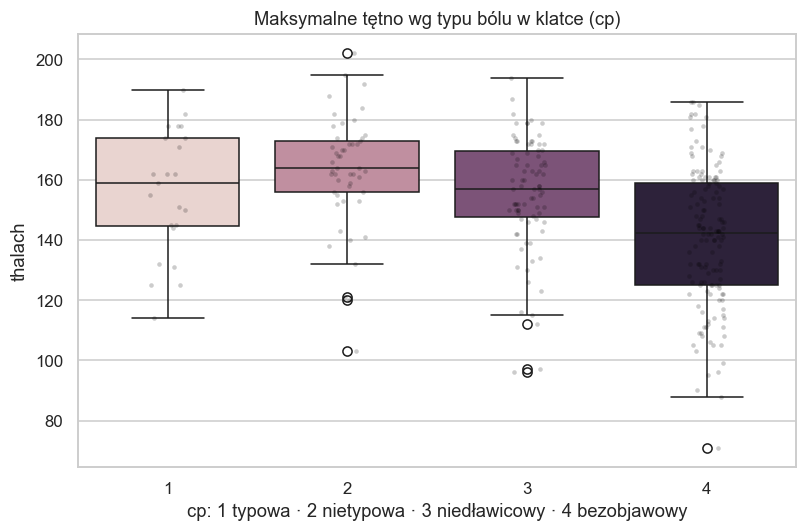

In [14]:
cpx = df.assign(cp=df["cp"].astype(int))
fig, ax = plt.subplots(figsize=(7.5, 5))
order = sorted(cpx["cp"].unique())
sns.boxplot(data=cpx, x="cp", y="thalach", hue="cp", legend=False, order=order, ax=ax)
sns.stripplot(data=cpx, x="cp", y="thalach", order=order, color="black", alpha=.2, size=3, ax=ax)
ax.set_title("Maksymalne tętno wg typu bólu w klatce (cp)")
ax.set_xlabel("cp: 1 typowa · 2 nietypowa · 3 niedławicowy · 4 bezobjawowy")
fig.tight_layout(); fig.savefig(FIG/"06_rq4_anova.png", bbox_inches="tight"); plt.show()

**Interpretacja RQ4.** Maksymalne tętno **różni się istotnie** między typami bólu w klatce
(ANOVA F=17,8, p≈1,3e−10). Uwaga (W3): **test Levene'a wskazuje na niejednorodność wariancji**
(p=0,035), więc wniosek opieramy dodatkowo na odpornym **teście Kruskala–Wallisa** (H=47,9, p≈2,3e−10) —
zgodnym z ANOVA. Post-hoc **Tukey HSD**: różnice wynikają głównie z typu **cp=4 (bezobjawowy)**,
który ma istotnie **niższe** tętno maksymalne niż typy 1–3 (o ~15–22 uderzeń/min); typy 1, 2, 3 nie różnią się między
sobą. Spójne z RQ6, gdzie cp=4 silnie wiąże się z chorobą.

## RQ5 — Czy choroba zależy od płci, a dławica wysiłkowa od statusu choroby?  *(W2, W3)*

- **Test (W2)**: tabele kontyngencji + **chi-kwadrat** niezależności; dla udziału chorych
  M vs K — test różnicy dwóch proporcji z **95% CI**.
- **Założenia (W3)**: liczności oczekiwane ≥ 5 (inaczej dokładny test Fishera).

In [15]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

ct_sex = pd.crosstab(df["sex"].astype(int), df["target"].astype(int))
ct_ex  = pd.crosstab(df["exang"].astype(int), df["target"].astype(int))
chi_sex = stats.chi2_contingency(ct_sex)
chi_ex  = stats.chi2_contingency(ct_ex)
print("Choroba wg płci (wiersze 0=K,1=M; kolumny 0=brak,1=choroba):\n", ct_sex)
print(f"chi2={chi_sex.statistic:.2f}, dof={chi_sex.dof}, p={chi_sex.pvalue:.3e}, "
      f"min. liczność oczekiwana={chi_sex.expected_freq.min():.1f}")
print("\nDławica wysiłkowa wg statusu choroby (wiersze 0=nie,1=tak):\n", ct_ex)
print(f"chi2={chi_ex.statistic:.2f}, dof={chi_ex.dof}, p={chi_ex.pvalue:.3e}")

male, female = df[df["sex"].astype(int)==1], df[df["sex"].astype(int)==0]
cm, nm = int(male["target"].astype(int).sum()), len(male)
cf, nf = int(female["target"].astype(int).sum()), len(female)
z, pz = proportions_ztest([cm, cf], [nm, nf])
lo, hi = confint_proportions_2indep(cm, nm, cf, nf)
print(f"\nUdział chorych: M={cm/nm:.1%} (n={nm}) vs K={cf/nf:.1%} (n={nf})")
print(f"różnica proporcji (M−K): z={z:.2f}, p={pz:.3e}; 95% CI=({lo:.3f}, {hi:.3f})")

Choroba wg płci (wiersze 0=K,1=M; kolumny 0=brak,1=choroba):
 target   0    1
sex            
0       71   25
1       89  112
chi2=21.85, dof=1, p=2.946e-06, min. liczność oczekiwana=44.3

Dławica wysiłkowa wg statusu choroby (wiersze 0=nie,1=tak):
 target    0   1
exang          
0       137  63
1        23  74
chi2=50.94, dof=1, p=9.511e-13

Udział chorych: M=55.7% (n=201) vs K=26.0% (n=96)
różnica proporcji (M−K): z=4.80, p=1.595e-06; 95% CI=(0.179, 0.399)


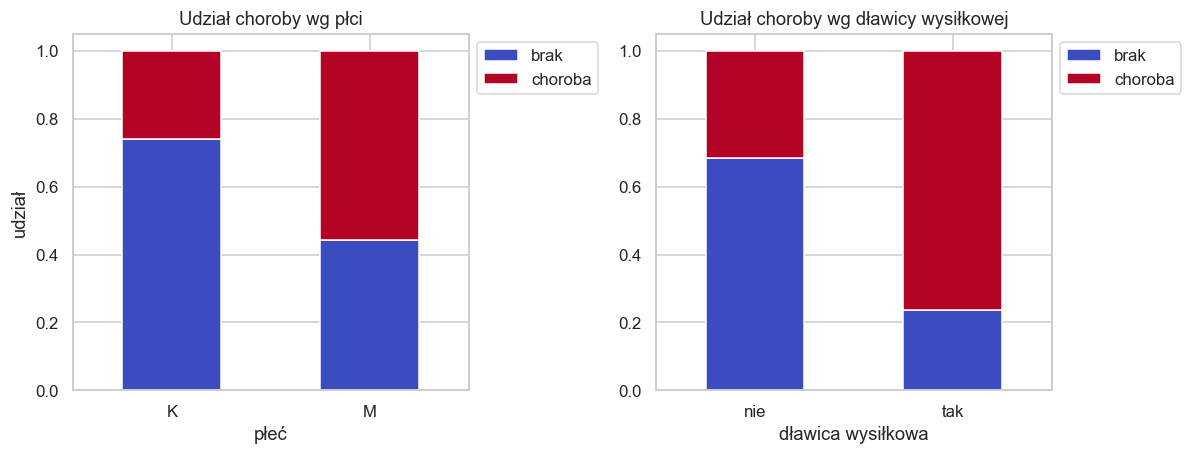

In [16]:
def share(col, labels):
    return (pd.crosstab(df[col].astype(int).map(labels),
                        df["target"].astype(int).map({0:"brak",1:"choroba"}),
                        normalize="index"))
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
share("sex", {0:"K",1:"M"}).plot.bar(stacked=True, ax=ax[0], colormap="coolwarm", rot=0)
ax[0].set_title("Udział choroby wg płci"); ax[0].set_xlabel("płeć"); ax[0].set_ylabel("udział")
share("exang", {0:"nie",1:"tak"}).plot.bar(stacked=True, ax=ax[1], colormap="coolwarm", rot=0)
ax[1].set_title("Udział choroby wg dławicy wysiłkowej"); ax[1].set_xlabel("dławica wysiłkowa")
for a in ax: a.legend(title="", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout(); fig.savefig(FIG/"07_rq5_proporcje.png", bbox_inches="tight"); plt.show()

**Interpretacja RQ5.** **Płeć**: choroba istotnie częstsza u mężczyzn — **55,7%** vs **26,0%**
u kobiet (chi²=21,9, p≈2,9e−6; różnica 29,7 pp, 95% CI 17,9–39,9 pp; liczności oczekiwane ≥5,
więc chi² zasadny). **Dławica wysiłkowa** (`exang`) bardzo silnie wiąże się z chorobą
(chi²=50,9, p≈9,5e−13): wśród osób z dławicą wysiłkową ~76% ma chorobę. Obie zmienne to mocne,
proste czynniki różnicujące — i potwierdzenie sygnałów z modelu wieloczynnikowego (RQ6).

## RQ6 — Model prawdopodobieństwa choroby (regresja logistyczna + ROC/AUC)  *(W1, W2, W3 — wyróżnik)*

- **Test (W2)**: wieloraka **regresja logistyczna** `target ~ age + sex + cp + thalach + oldpeak + ca`;
  interpretacja przez **ilorazy szans** (OR) z 95% CI.
- **Ocena**: krzywa **ROC** + **AUC**, macierz pomyłek; dla uczciwej oceny uogólnienia —
  **5-krotna walidacja krzyżowa** AUC.
- **Założenia (W3)**: brak silnej współliniowości (por. VIF z RQ3), obserwacje wpływowe,
  liniowość logitu dla predyktorów ciągłych.

In [17]:
dfm = df.copy(); dfm["target"] = dfm["target"].astype(int)
logit = smf.logit("target ~ age + C(sex) + C(cp) + thalach + oldpeak + ca", data=dfm).fit(disp=False)
print(logit.summary())

ci = logit.conf_int()
orr = pd.DataFrame({"OR": np.exp(logit.params), "2.5%": np.exp(ci[0]), "97.5%": np.exp(ci[1])})
print("\nIlorazy szans (OR) z 95% CI:\n", orr.round(3))

                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  297
Model:                          Logit   Df Residuals:                      288
Method:                           MLE   Df Model:                            8
Date:                Wed, 10 Jun 2026   Pseudo R-squ.:                  0.4402
Time:                        20:48:35   Log-Likelihood:                -114.75
converged:                       True   LL-Null:                       -204.97
Covariance Type:            nonrobust   LLR p-value:                 8.283e-35
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.7536      2.252     -0.335      0.738      -5.168       3.661
C(sex)[T.1]     1.5303      0.394      3.880      0.000       0.757       2.303
C(cp)[T.2]      0.6974      0.704      0.991    

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

proba = logit.predict(dfm)
auc = roc_auc_score(dfm["target"], proba)
fpr, tpr, _ = roc_curve(dfm["target"], proba)

Xcv = pd.get_dummies(dfm[["age","sex","cp","thalach","oldpeak","ca"]], columns=["sex","cp"],
                     drop_first=True).astype(float)
ycv = dfm["target"].values
cv = StratifiedKFold(5, shuffle=True, random_state=42)
aucs = []
for tr, te in cv.split(Xcv, ycv):
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    pipe.fit(Xcv.iloc[tr], ycv[tr])
    aucs.append(roc_auc_score(ycv[te], pipe.predict_proba(Xcv.iloc[te])[:, 1]))
cmle = confusion_matrix(dfm["target"], (proba >= 0.5).astype(int))
print(f"AUC (dane uczące) = {auc:.3f}")
print(f"AUC (walidacja 5-krotna) = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
print("Macierz pomyłek (próg 0,5) [wiersze: prawda 0/1; kolumny: predykcja 0/1]:\n", cmle)

AUC (dane uczące) = 0.905
AUC (walidacja 5-krotna) = 0.890 ± 0.036
Macierz pomyłek (próg 0,5) [wiersze: prawda 0/1; kolumny: predykcja 0/1]:
 [[140  20]
 [ 34 103]]


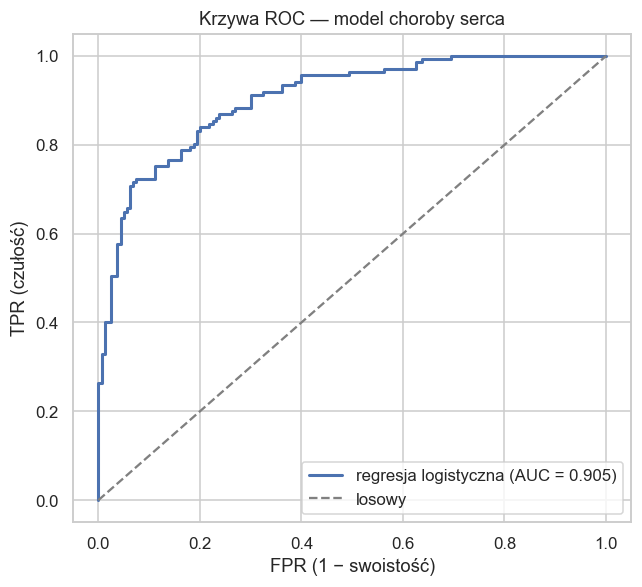

In [19]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(fpr, tpr, lw=2, label=f"regresja logistyczna (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color="grey", label="losowy")
ax.set_xlabel("FPR (1 − swoistość)"); ax.set_ylabel("TPR (czułość)")
ax.set_title("Krzywa ROC — model choroby serca"); ax.legend(loc="lower right")
fig.tight_layout(); fig.savefig(FIG/"08_rq6_roc.png", bbox_inches="tight"); plt.show()

**Interpretacja RQ6.** Model logistyczny jest bardzo dobry: **Pseudo R²=0,44**, **AUC=0,905**
na danych uczących i **0,890 ± 0,036 w 5-krotnej walidacji krzyżowej** — wysoka i **stabilna** zdolność
dyskryminacji (brak przeuczenia). Istotne czynniki ryzyka (iloraz szans OR): **płeć męska OR=4,6**,
**cp=4 bezobjawowy OR=8,3**, **ca OR=2,7** (na każde naczynie), **oldpeak OR=1,9**; **thalach OR=0,98**
działa ochronnie (wyższe tętno maks. → niższe ryzyko). Wiek po uwzględnieniu pozostałych zmiennych
jest **nieistotny** (OR≈1,01, p=0,61) — jego efekt przejmują skorelowane predyktory. Przy progu 0,5:
trafność 81,8%, czułość 75,2%, swoistość 87,5%.

## Wnioski

Z analizy publicznego zbioru UCI Heart Disease (n=297) wyłania się spójny obraz czynników ryzyka:

- **Cholesterol** (RQ1) sam w sobie **słabo** różnicuje chorych i zdrowych — co pokazuje, że wnioskowanie
  zależy od spełnienia założeń (test t i Mann–Whitney prowadzą do odmiennych wniosków).
- **Maksymalne tętno** maleje z wiekiem (RQ2: ~1 uderzenie/min na rok) i z obniżeniem ST (RQ3);
  niższe tętno maksymalne wiąże się z wyższym ryzykiem choroby (RQ6).
- **Typ bólu w klatce** ma znaczenie: postać **bezobjawowa (cp=4)** wyróżnia się niższym tętnem
  (RQ4) i najwyższym ryzykiem choroby (RQ6).
- **Płeć męska**, **dławica wysiłkowa**, liczba naczyń **ca** i **oldpeak** to najsilniejsze
  czynniki ryzyka (RQ5, RQ6).
- Model logistyczny osiąga **AUC≈0,89** w walidacji krzyżowej — wysoką i stabilną zdolność predykcyjną.

**Ograniczenia.** Dane historyczne (koniec lat 80.), jeden ośrodek (Cleveland), n≈300, zmienne
zakodowane medycznie; możliwe obserwacje wpływowe (RQ3). Wyniki są **obserwacyjne**
(korelacja ≠ przyczynowość). Dalsze kroki: walidacja na pełnym zbiorze 4 ośrodków, regularyzacja,
analiza interakcji i nieliniowości (np. wiek × płeć).

_Analizy realizują efekty uczenia: W1–W3 (statystyka i weryfikacja założeń), U1–U3
(wizualizacja i komunikacja wyników)._